# Giai đoạn 5 — Học phân phối của từng ngành

```
┌────────────────────────────────────────────────────────────────────────────────────────┐
│                                     05_HocPhanPhoi                                     │
└────────────────────────────────────────────────────────────────────────────────────────┘

  ĐẦU VÀO
    • 03_TachTrainTest/khaosat_train.csv  —  574 phiếu
    • 03_TachTrainTest/cv_folds.json      —  15 fold
         │
         ▼
  XỬ LÝ
    1. Với mỗi ngành, học từ phiếu khảo sát của ngành đó:
    2.    · 10 câu Likert  → vector trung bình μ (10) + ma trận hiệp phương sai Σ (10×10)
    3.    · giới tính      → tỉ lệ Nam
    4.    · mục tiêu       → phân phối trên 4 lựa chọn
    5. CO NGÓT BAYES về mức khối — ngành ít phiếu thì tin khối nhiều hơn
    6. Học RIÊNG cho từng fold để không rò rỉ dữ liệu
         │
         ▼
  ĐẦU RA
    • 05_HocPhanPhoi/phan_phoi_theo_fold.npz
    • 05_HocPhanPhoi/suc_co_ngot.csv
    • 05_HocPhanPhoi/hinh_5_*.png         —  3 hình
```

## Vấn đề: ngành ít nhất chỉ có 6 phiếu

Muốn sinh dữ liệu giống thật cho ngành *Quản lý Công nghiệp*, ta phải biết học sinh ngành đó trả
lời 10 câu Likert như thế nào. Nhưng ngành đó chỉ có **6 phiếu** trong tập train.

Ước lượng ma trận hiệp phương sai 10×10 — tức **55 tham số độc lập** — từ 6 dòng dữ liệu là vô
vọng. Kết quả sẽ là một ma trận suy biến, phản ánh 6 người cụ thể đó chứ không phản ánh ngành.

## Cách xử lý: co ngót Bayes

Ý tưởng: **ngành ít phiếu thì tin vào khối nhiều hơn, ngành nhiều phiếu thì tin vào chính nó**.

```
        n_ngành
w = ─────────────           K = 8 (số phiếu "ảo" của tiên nghiệm)
     n_ngành + K

μ_dùng = w · μ_ngành  +  (1 − w) · μ_khối
Σ_dùng = w · Σ_ngành  +  (1 − w) · Σ_khối
```

| Ngành có | w | Nghĩa là |
|---|---|---|
| 6 phiếu | 0,43 | tin ngành 43%, tin khối 57% |
| 24 phiếu | 0,75 | tin ngành 75% |
| 47 phiếu | 0,85 | tin ngành 85% |

`K = 8` nghĩa là: *"tiên nghiệm ở mức khối đáng tin bằng khoảng 8 phiếu khảo sát"*. Ngành nào có
đúng 8 phiếu thì tin hai bên ngang nhau.

## Vì sao học RIÊNG cho từng fold

Nếu học phân phối từ cả 574 dòng rồi dùng nó sinh dữ liệu huấn luyện cho mọi fold, thì phần
validation của mỗi fold đã gián tiếp góp phần tạo ra dữ liệu huấn luyện — **rò rỉ**.

Học riêng 15 lần, mỗi lần chỉ từ phần train của fold đó, thì phần validation hoàn toàn sạch.


In [1]:
import json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

warnings.filterwarnings("ignore")

PROC = Path("../data/processed")
RAW  = Path("../data/raw")
SEED = 42
np.random.seed(SEED)

# Web gửi limit=3 (web/src/app/(main)/predict/page.tsx) nên Top-3 là chỉ tiêu
# chính; Top-1/2/5 báo cáo kèm để thấy toàn cảnh.
TOP_K = (1, 2, 3, 5)

# Thư mục đầu ra trùng khít tên notebook
GIAI_DOAN = {
    1: "01_LamSachKhaoSat",
    2: "02_ChuanBiTTTH",
    3: "03_TachTrainTest",
    4: "04_MocChuan",
    5: "05_HocPhanPhoi",
    6: "06_GA_TangCuong",
    7: "07_KiemDinhGA",
    8: "08_TrainFinal",
    9: "09_TinhChinh",
    10: "10_ChotModel",
}


def thu_muc(i):
    """Thư mục đầu ra của giai đoạn i, tạo sẵn nếu chưa có."""
    p = PROC / GIAI_DOAN[i]
    p.mkdir(parents=True, exist_ok=True)
    return p


# ── Kiểu biểu đồ thống nhất cho toàn bộ báo cáo ──────────────────────────────
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 220, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 14,
    "axes.labelsize": 11, "axes.labelpad": 8,
    "axes.grid": True, "grid.alpha": 0.18, "grid.linestyle": "-", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.edgecolor": "#B0B7BF",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False, "legend.fontsize": 10,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "xtick.color": "#4A5560", "ytick.color": "#4A5560",
    "axes.labelcolor": "#2C3E50", "text.color": "#2C3E50",
})

C_THAT = "#D64550"   # dữ liệu thật
C_GA   = "#2BA84A"   # dữ liệu tổng hợp (GA)
C_XANH = "#3B7DD8"   # nhấn mạnh chính
C_CAM  = "#E8873A"   # nhấn mạnh phụ
C_TIM  = "#8E5FBF"
C_XAM  = "#AEB6BF"   # nền / mốc so sánh
C_DAM  = "#2C3E50"
C_NHOM = plt.get_cmap("tab20")(np.linspace(0, 1, 20))


def nhan_ngang(ax, gia_tri, fmt="{:,.0f}", lui=0.012, fs=10, mau=None):
    """Ghi số ở cuối mỗi thanh ngang."""
    lim = ax.get_xlim()[1]
    for i, v in enumerate(gia_tri):
        ax.text(v + lim * lui, i, fmt.format(v), va="center", fontsize=fs,
                fontweight="bold", color=mau or C_DAM)


def nhan_doc(ax, fmt="{:,.0f}", lui=0.02, fs=10):
    """Ghi số trên đầu mỗi cột dọc."""
    lim = ax.get_ylim()[1]
    for p in ax.patches:
        h = p.get_height()
        if h and abs(h) > 1e-9:
            ax.text(p.get_x() + p.get_width() / 2, h + lim * lui, fmt.format(h),
                    ha="center", va="bottom", fontsize=fs, fontweight="bold", color=C_DAM)


def chu_thich(fig, text, y=None):
    """Dòng chú giải dưới hình — nêu KẾT LUẬN rút ra, không mô tả lại hình.

    Chú giải (legend) đặt ngoài trục bằng bbox_to_anchor y âm có thể thò xuống
    dưới đáy hình; khi đó phải hạ dòng chú thích xuống dưới nó, nếu không hai bên
    đè lên nhau (bbox_inches="tight" nới khung chứ không dời chữ ra).
    """
    if y is None:
        y = -0.02
        fig.canvas.draw()
        r = fig.canvas.get_renderer()
        hop_ds = [lg.get_window_extent(r) for lg in fig.legends]
        hop_ds += [ax.get_legend().get_window_extent(r)
                   for ax in fig.axes if ax.get_legend() is not None]
        for hop in hop_ds:
            day = hop.transformed(fig.transFigure.inverted()).y0
            if day < y:
                y = day - 0.035
    fig.text(0.5, y, text, ha="center", va="top", fontsize=10.5,
             color="#5A6672", style="italic", wrap=True)


def ngat_dong(s, n=18):
    """Ngắt chuỗi dài thành nhiều dòng thay vì cắt cụt — nhãn vẫn đọc được hết."""
    tu, dong, cur = str(s).split(), [], ""
    for t in tu:
        if len(cur) + len(t) + 1 <= n or not cur:
            cur = f"{cur} {t}".strip()
        else:
            dong.append(cur); cur = t
    if cur:
        dong.append(cur)
    return "\n".join(dong)


def cho_chu_giai(ax, ngang=True, phan=0.28):
    """Nới trục để CHỪA CHỖ cho chú giải, tránh nó đè lên cột.

    Chú giải đặt trong vùng vẽ luôn có nguy cơ chồng lên dữ liệu. Cách chắc ăn
    là nới giới hạn trục thêm `phan` rồi đặt chú giải vào khoảng trống đó.
    """
    if ngang:
        lo, hi = ax.get_xlim(); ax.set_xlim(lo, hi + (hi - lo) * phan)
    else:
        lo, hi = ax.get_ylim(); ax.set_ylim(lo, hi + (hi - lo) * phan)


def cao_theo_dong(n, moi_dong=0.26, toi_thieu=4.5, toi_da=13):
    """Chiều cao hình cho biểu đồ cột ngang — 39 nhãn cần ~11 inch, không phải 7."""
    return float(np.clip(n * moi_dong + 2.0, toi_thieu, toi_da))


def luu(fig, ra, ten, chu=None):
    if chu:
        chu_thich(fig, chu)
    fig.savefig(ra / ten, dpi=220, bbox_inches="tight", facecolor="white")
    print(f"   💾 {ten}")


def tom_tat(tieu_de, dong_ds, rong=76):
    """Bảng tóm tắt cuối notebook — mỗi giai đoạn kết thúc bằng một cái."""
    print("╔" + "═" * rong + "╗")
    print("║" + f" {tieu_de} ".center(rong) + "║")
    print("╠" + "═" * rong + "╣")
    for d in dong_ds:
        print("║ " + str(d)[: rong - 2].ljust(rong - 1) + "║")
    print("╚" + "═" * rong + "╝")

def nap(co_test=False, co_ttth=True):
    """Đọc mọi thứ notebook huấn luyện cần.

    `co_test=True` CHỈ được bật ở Giai đoạn 10 — mở tập test đúng một lần.

    Khoá "nhom" đọc từ `nganh_to_nhom` trong mapping.json. Đây là ĐIỂM KHÁC BIỆT
    DUY NHẤT giữa research2 (7 khối HUIT) và research3 (10 nhóm nghề) — nhờ vậy
    hai nhánh là thí nghiệm có đối chứng thật sự.
    """
    m = json.loads((thu_muc(1) / "mapping.json").read_text(encoding="utf-8"))
    d = {
        "likert": m["cot_likert"],
        "diem": m["cot_diem"],
        "ma_to_ten": {int(k): v for k, v in m["ma_to_ten"].items()},
        "nhom": {int(k): v for k, v in m["nganh_to_nhom"].items()},
        "ten_nhom": {int(k): v for k, v in m["ten_nhom"].items()},
        "ten_cach_nhom": m.get("ten_cach_nhom", "nhóm ngành"),
        "train": pd.read_csv(thu_muc(3) / "khaosat_train.csv"),
        "folds": json.loads((thu_muc(3) / "cv_folds.json").read_text(encoding="utf-8")),
    }
    d["ttth"] = pd.read_csv(thu_muc(2) / "ttth_sach.csv") if co_ttth else pd.DataFrame()
    if co_test:
        d["test"] = pd.read_csv(thu_muc(3) / "khaosat_test_KHOA.csv")

    nguon = [d["train"].to_hop_thi.str.split(" ").str[0]]
    if co_ttth:
        nguon.append(d["ttth"].to_hop_thi.astype(str))
    d["to_hop"] = sorted(set().union(*[set(s) for s in nguon]))
    d["nganh"] = np.sort(d["train"].ma_nganh.unique())
    d["i_nganh"] = {m_: i for i, m_ in enumerate(d["nganh"])}

    # Thống kê điểm để quy z-score. Tính trên TRAIN (+ TTTH nếu dùng), tuyệt đối
    # không đụng test — nếu không thì thông tin test rò rỉ qua bước chuẩn hoá.
    goc = [d["train"][d["diem"]]] + ([d["ttth"][d["diem"]]] if co_ttth else [])
    g = pd.concat(goc).astype(float)
    d["diem_mu"] = g.mean().values
    d["diem_sd"] = g.std().replace(0, 1).values
    return d


def dac_trung(df, D, co_khao_sat=True):
    """Ma trận 63 đặc trưng — MỘT định nghĩa duy nhất cho cả hai nguồn dữ liệu.

    `co_khao_sat=False` dùng cho hồ sơ trúng tuyển: nguồn này chỉ có điểm thi và
    tổ hợp. Cột thiếu để NaN chứ không điền bừa — XGBoost học luôn hướng rẽ cho
    giá trị thiếu ngay trong thuật toán, còn điền bừa tạo ra giá trị không có thật.
    """
    n = len(df)
    L, C_DIEM = D["likert"], D["diem"]
    th = df["to_hop_thi"].astype(str).str.split(" ").str[0].values
    Dm = df[C_DIEM].astype(float).values
    Lk = df[L].astype(float).values if co_khao_sat else np.full((n, len(L)), np.nan)

    ph = [pd.DataFrame(Lk, columns=L)]

    # Likert chuẩn hoá theo từng người: người hay chọn 4-5 và người hay chọn 2-3
    # cùng "thích logic nhất" nhưng để thô thì mô hình đọc thành hai hồ sơ khác
    # hẳn. Trừ trung bình của chính người đó thì còn lại sở thích TƯƠNG ĐỐI.
    with np.errstate(invalid="ignore"):
        mu = np.nanmean(Lk, 1, keepdims=True)
        sd = np.nanstd(Lk, 1, keepdims=True)
    sd = np.where((sd == 0) | np.isnan(sd), 1.0, sd)
    ph.append(pd.DataFrame(Lk - mu, columns=[f"ips_{c}" for c in L]))
    ph.append(pd.DataFrame({"likert_tb": mu[:, 0], "likert_dolech": sd[:, 0]}))

    ph.append(pd.DataFrame(Dm, columns=C_DIEM))
    # 8.0 môn Toán và 8.0 môn Văn không cùng ý nghĩa — quy z-score mới so được
    z = (Dm - D["diem_mu"]) / D["diem_sd"]
    ph.append(pd.DataFrame(z, columns=[f"z_{c}" for c in C_DIEM]))
    with np.errstate(invalid="ignore", divide="ignore"):
        ph.append(pd.DataFrame({
            "diem_tb": np.nanmean(Dm, 1),
            "diem_lech": np.nanmax(Dm, 1) - np.nanmin(Dm, 1),
            "z_tb": np.nanmean(z, 1),
            "z_max": np.nanmax(z, 1),
        }))

    # Tổ hợp là dữ liệu phân loại, KHÔNG có thứ tự. Mã hoá thành số (A00=0,
    # A01=1…) sẽ dạy mô hình rằng D01 "lớn hơn" A00 và trung bình A00 với B00 ra
    # A01 — vô nghĩa. One-hot tránh được: mỗi cột chỉ hỏi "có thi tổ hợp này không".
    ph.append(pd.DataFrame({f"th_{t}": (th == t).astype(float) for t in D["to_hop"]}))
    gt = ((df["gioi_tinh"] == "Nam").astype(float).values if "gioi_tinh" in df
          else np.full(n, np.nan))
    mt = (df["muc_tieu_ma"].astype(float).values if "muc_tieu_ma" in df
          else np.full(n, np.nan))
    ph.append(pd.DataFrame({"gioi_tinh_nam": gt, "muc_tieu": mt}))
    return pd.concat([p.reset_index(drop=True) for p in ph], axis=1)


def nhom_dac_trung(cols, D):
    """Gom tên cột thành 8 nhóm — dùng khi in bảng thống kê và vẽ hình."""
    L, C_DIEM = D["likert"], D["diem"]
    return {
        "Likert thô": [c for c in cols if c in L],
        "Likert chuẩn hoá theo người": [c for c in cols if c.startswith("ips_")],
        "Thống kê Likert": [c for c in cols if c in ("likert_tb", "likert_dolech")],
        "Điểm thi thô": [c for c in cols if c in C_DIEM],
        "Điểm z-score từng môn": [c for c in cols if c.startswith("z_diem_")],
        "Phái sinh từ điểm": [c for c in cols
                              if c in ("diem_tb", "diem_lech", "z_tb", "z_max")],
        "Tổ hợp xét tuyển (one-hot)": [c for c in cols if c.startswith("th_")],
        "Nhân khẩu học & mục tiêu": [c for c in cols
                                     if c in ("gioi_tinh_nam", "muc_tieu")],
    }

OUT = thu_muc(5)
K_CO_NGOT = 8         # số phiếu "ảo" của tiên nghiệm mức khối
N_MUC_TIEU = 4

D = nap(co_ttth=False)
ks = D["train"]
L = D["likert"]
y = ks.ma_nganh.values
NG = D["nganh"]
I_NG = D["i_nganh"]
nhom_sv = np.array([D["nhom"][m] for m in y])
FOLDS = D["folds"]["folds"]
Lk = ks[L].astype(float).values
gt = (ks.gioi_tinh == "Nam").astype(float).values
mt = ks.muc_tieu_ma.astype(int).values

co = pd.Series(y).value_counts()
print(f"Dữ liệu : {len(ks)} phiếu · {len(NG)} ngành")
print(f"Ngành   : ít nhất {co.min()} phiếu · nhiều nhất {co.max()} phiếu")
print(f"Học     : μ(10) + Σ(10×10) + P(Nam) + P(mục tiêu) cho mỗi ngành,"
      f" riêng từng fold trong {len(FOLDS)} fold")
print(f"Co ngót : K = {K_CO_NGOT} phiếu ảo")

Dữ liệu : 574 phiếu · 39 ngành
Ngành   : ít nhất 5 phiếu · nhiều nhất 40 phiếu
Học     : μ(10) + Σ(10×10) + P(Nam) + P(mục tiêu) cho mỗi ngành, riêng từng fold trong 15 fold
Co ngót : K = 8 phiếu ảo


## 1. Hàm học phân phối

In [2]:
def hoc_mot_fold(idx):
    """Học phân phối mọi ngành, CHỈ từ các dòng trong `idx`."""
    mu = np.zeros((len(NG), len(L)))
    sig = np.zeros((len(NG), len(L), len(L)))
    p_nam = np.zeros(len(NG))
    p_mt = np.zeros((len(NG), N_MUC_TIEU))
    w_ra = np.zeros(len(NG))

    # Mức TOÀN BỘ — chỗ dựa cuối cùng cho khối cũng ít dữ liệu
    mu_all = Lk[idx].mean(0)
    sig_all = np.cov(Lk[idx].T) + np.eye(len(L)) * 1e-3
    nam_all = gt[idx].mean()
    mt_all = np.bincount(mt[idx] - 1, minlength=N_MUC_TIEU) / len(idx)

    # Mức KHỐI
    muc_khoi = {}
    for g in sorted(set(D["nhom"].values())):
        sel = idx[nhom_sv[idx] == g]
        if len(sel) < 3:
            muc_khoi[g] = (mu_all, sig_all, nam_all, mt_all)
            continue
        s = np.cov(Lk[sel].T) if len(sel) > len(L) else sig_all
        muc_khoi[g] = (
            Lk[sel].mean(0), s + np.eye(len(L)) * 1e-3, gt[sel].mean(),
            (np.bincount(mt[sel] - 1, minlength=N_MUC_TIEU) + 1) / (len(sel) + N_MUC_TIEU))

    # Mức NGÀNH + co ngót
    for ma in NG:
        i = I_NG[ma]
        sel = idx[y[idx] == ma]
        mk, sk, nk, tk = muc_khoi[D["nhom"][ma]]
        n = len(sel)
        w = n / (n + K_CO_NGOT)
        w_ra[i] = w
        if n == 0:
            mu[i], sig[i], p_nam[i], p_mt[i] = mk, sk, nk, tk
            continue
        m_n = Lk[sel].mean(0)
        s_n = np.cov(Lk[sel].T) if n > 1 else np.zeros((len(L), len(L)))
        if np.isnan(s_n).any():
            s_n = np.zeros((len(L), len(L)))
        mu[i] = w * m_n + (1 - w) * mk
        sig[i] = w * s_n + (1 - w) * sk + np.eye(len(L)) * 1e-3
        p_nam[i] = w * gt[sel].mean() + (1 - w) * nk
        t_n = (np.bincount(mt[sel] - 1, minlength=N_MUC_TIEU) + .5) / (n + .5 * N_MUC_TIEU)
        p_mt[i] = w * t_n + (1 - w) * tk
        p_mt[i] /= p_mt[i].sum()
    return mu, sig, p_nam, p_mt, w_ra


t0 = time.time()
MU, SIG, PNAM, PMT, WW = [], [], [], [], []
for f in FOLDS:
    a, b, c, d_, e = hoc_mot_fold(np.array(f["train_idx"]))
    MU.append(a); SIG.append(b); PNAM.append(c); PMT.append(d_); WW.append(e)
# Thêm một bản học từ TOÀN BỘ tập train — dùng cho mô hình cuối ở Giai đoạn 10.
# Hợp lệ vì tập test vẫn nằm ngoài; chỉ có bản theo fold mới dùng cho CV.
mu_f, sig_f, pn_f, pm_f, w_f = hoc_mot_fold(np.arange(len(ks)))
MU, SIG = np.array(MU), np.array(SIG)
PNAM, PMT, WW = np.array(PNAM), np.array(PMT), np.array(WW)
print(f"Học xong {len(FOLDS)} fold trong {time.time()-t0:.0f}s")
print(f"   μ    {MU.shape}")
print(f"   Σ    {SIG.shape}")
print(f"   P(Nam) {PNAM.shape} · P(mục tiêu) {PMT.shape}")

# Mọi Σ phải xác định dương, nếu không thì không lấy mẫu được
xau = 0
for i in range(len(FOLDS)):
    for j in range(len(NG)):
        if np.linalg.eigvalsh(SIG[i, j]).min() <= 0:
            xau += 1
print(f"\n✓ Ma trận Σ không xác định dương: {xau}/{len(FOLDS)*len(NG)}")
assert xau == 0, "có Σ suy biến — tăng K_CO_NGOT hoặc epsilon"

Học xong 15 fold trong 0s
   μ    (15, 39, 10)
   Σ    (15, 39, 10, 10)
   P(Nam) (15, 39) · P(mục tiêu) (15, 39, 4)

✓ Ma trận Σ không xác định dương: 0/585


   💾 hinh_5_1_co_ngot.png


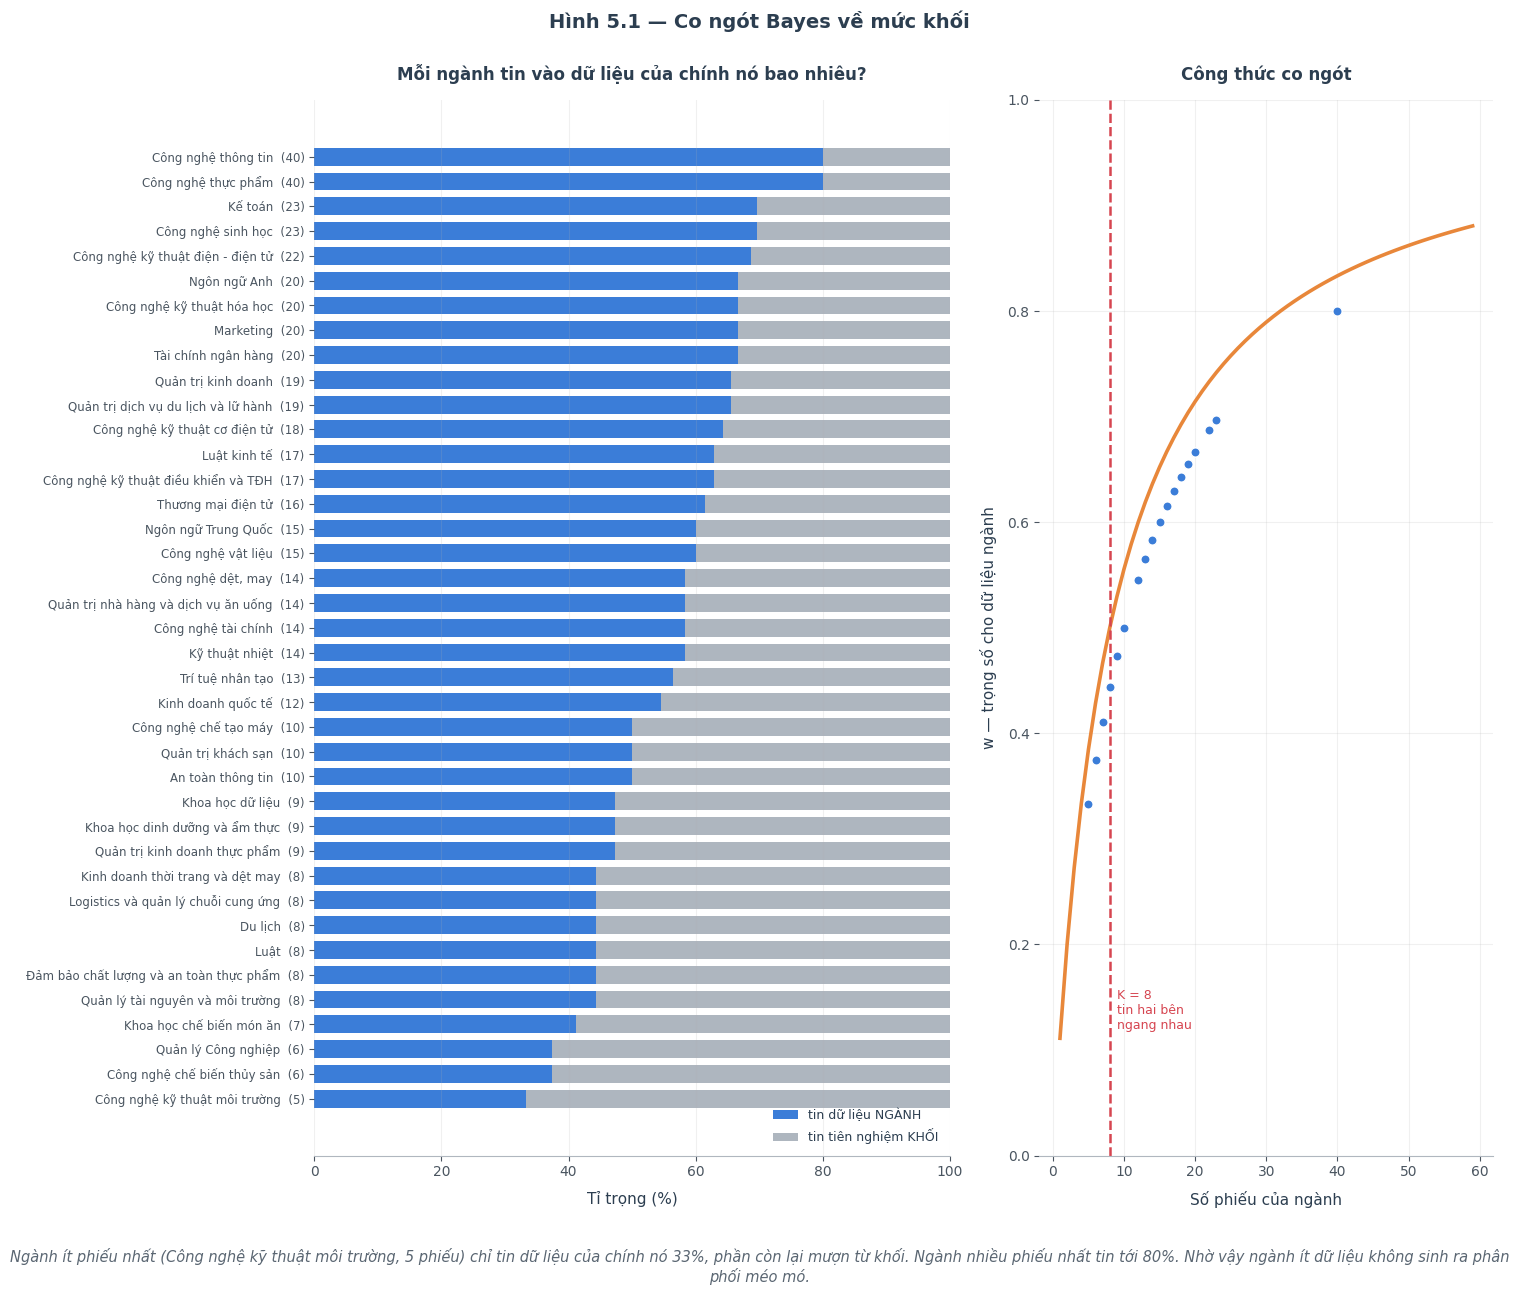

In [3]:
# ═══════════ HÌNH 5.1 — Sức co ngót ═══════════
w_tb = WW.mean(0)
sc = pd.DataFrame({"ma_nganh": NG, "n_phieu": [int(co.get(m, 0)) for m in NG],
                   "w": w_tb, "tin_nganh": w_tb, "tin_khoi": 1 - w_tb})
sc["nganh"] = [D["ma_to_ten"][m] for m in NG]
sc = sc.sort_values("n_phieu")
sc.to_csv(OUT / "suc_co_ngot.csv", index=False)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, cao_theo_dong(len(sc))),
                             gridspec_kw={"width_ratios": [1.4, 1]})
yy = np.arange(len(sc))
a1.barh(yy, sc.tin_nganh * 100, color=C_XANH, height=.72, label="tin dữ liệu NGÀNH")
a1.barh(yy, sc.tin_khoi * 100, left=sc.tin_nganh * 100, color=C_XAM, height=.72,
        label="tin tiên nghiệm KHỐI")
a1.set_yticks(yy)
a1.set_yticklabels([f"{r.nganh}  ({r.n_phieu})" for r in sc.itertuples()], fontsize=8.5)
a1.set_xlabel("Tỉ trọng (%)"); a1.set_xlim(0, 100)
a1.set_title("Mỗi ngành tin vào dữ liệu của chính nó bao nhiêu?", fontsize=12)
a1.legend(loc="lower right", fontsize=9); a1.grid(axis="y", alpha=0)

n_ = np.arange(1, 60)
a2.plot(n_, n_ / (n_ + K_CO_NGOT), color=C_CAM, lw=2.6)
a2.scatter(sc.n_phieu, sc.w, s=42, color=C_XANH, zorder=3, edgecolor="white", lw=.8)
a2.axvline(K_CO_NGOT, color=C_THAT, ls="--", lw=1.8)
a2.text(K_CO_NGOT + 1, .12, f"K = {K_CO_NGOT}\ntin hai bên\nngang nhau",
        fontsize=9, color=C_THAT)
a2.set_xlabel("Số phiếu của ngành"); a2.set_ylabel("w — trọng số cho dữ liệu ngành")
a2.set_title("Công thức co ngót", fontsize=12); a2.set_ylim(0, 1)

fig.suptitle("Hình 5.1 — Co ngót Bayes về mức khối", fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
luu(fig, OUT, "hinh_5_1_co_ngot.png",
    f"Ngành ít phiếu nhất ({sc.iloc[0].nganh}, {sc.iloc[0].n_phieu} phiếu) chỉ tin dữ liệu của "
    f"chính nó {sc.iloc[0].w:.0%}, phần còn lại mượn từ khối. Ngành nhiều phiếu nhất tin tới "
    f"{sc.w.max():.0%}. Nhờ vậy ngành ít dữ liệu không sinh ra phân phối méo mó.")
plt.show()

   💾 hinh_5_2_ho_so_khoi.png


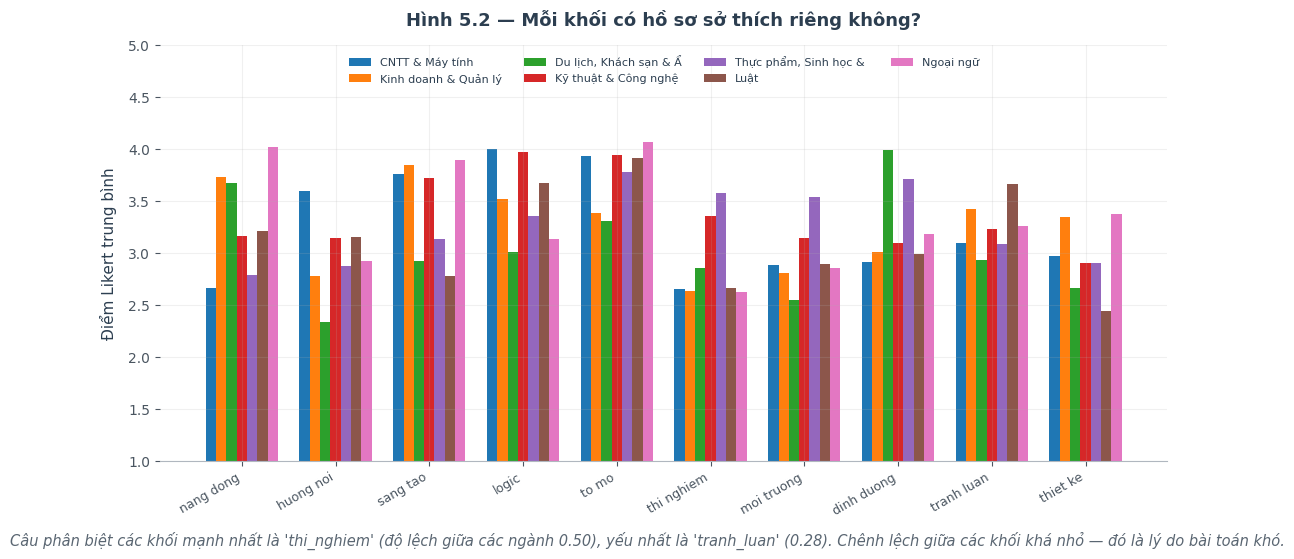

In [4]:
# ═══════════ HÌNH 5.2 — Hồ sơ Likert theo khối ═══════════
fig, ax = plt.subplots(figsize=(13, 5.4))
x = np.arange(len(L)); w_ = .11
for g in sorted(set(D["nhom"].values())):
    ngs = [I_NG[m] for m in NG if D["nhom"][m] == g]
    v = MU[:, ngs].mean(axis=(0, 1))
    ax.bar(x + (g - 3) * w_, v, w_, label=f"{D['ten_nhom'][g][:22]}")
ax.set_xticks(x)
ax.set_xticklabels([c.replace("likert_", "").replace("_", " ") for c in L],
                   rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Điểm Likert trung bình"); ax.set_ylim(1, 5)
ax.set_title("Hình 5.2 — Mỗi khối có hồ sơ sở thích riêng không?")
ax.legend(fontsize=8, ncol=4, loc="upper center")
bien = MU.mean(0).std(0)
luu(fig, OUT, "hinh_5_2_ho_so_khoi.png",
    f"Câu phân biệt các khối mạnh nhất là "
    f"'{L[int(bien.argmax())].replace('likert_','')}' (độ lệch giữa các ngành "
    f"{bien.max():.2f}), yếu nhất là '{L[int(bien.argmin())].replace('likert_','')}' "
    f"({bien.min():.2f}). Chênh lệch giữa các khối khá nhỏ — đó là lý do bài toán khó.")
plt.show()

   💾 hinh_5_3_gioitinh_muctieu.png


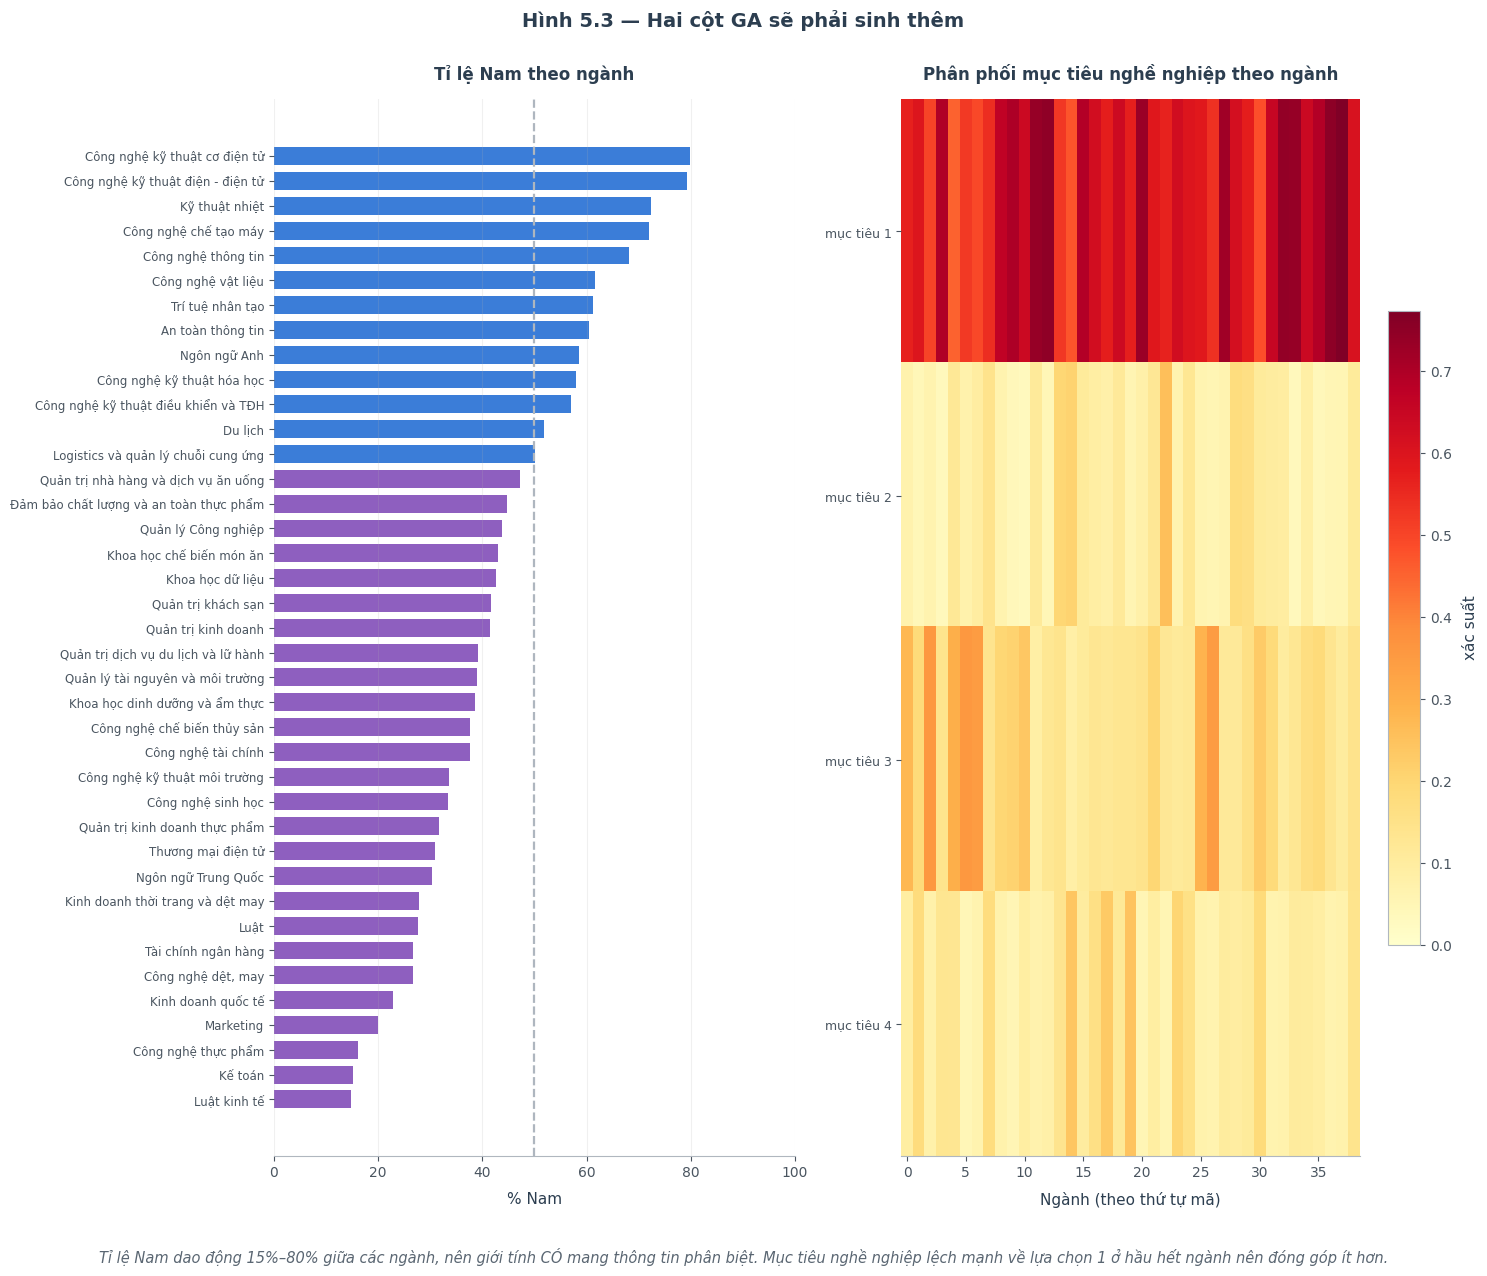

In [5]:
# ═══════════ HÌNH 5.3 — Giới tính và mục tiêu ═══════════
pn = pd.DataFrame({"nganh": [D["ma_to_ten"][m] for m in NG],
                   "p_nam": PNAM.mean(0)}).sort_values("p_nam")
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, cao_theo_dong(len(pn))),
                             gridspec_kw={"width_ratios": [1, 1.1]})
yy = np.arange(len(pn))
a1.barh(yy, pn.p_nam * 100, color=[C_XANH if v > .5 else C_TIM for v in pn.p_nam],
        height=.72)
a1.axvline(50, color=C_XAM, ls="--", lw=1.6)
a1.set_yticks(yy); a1.set_yticklabels(list(pn.nganh), fontsize=8.5)
a1.set_xlabel("% Nam"); a1.set_xlim(0, 100)
a1.set_title("Tỉ lệ Nam theo ngành", fontsize=12); a1.grid(axis="y", alpha=0)

pm = PMT.mean(0)
im = a2.imshow(pm.T, aspect="auto", cmap="YlOrRd", vmin=0, vmax=pm.max())
a2.set_yticks(range(N_MUC_TIEU))
a2.set_yticklabels([f"mục tiêu {i+1}" for i in range(N_MUC_TIEU)], fontsize=9)
a2.set_xlabel("Ngành (theo thứ tự mã)")
a2.set_title("Phân phối mục tiêu nghề nghiệp theo ngành", fontsize=12)
a2.grid(alpha=0); fig.colorbar(im, ax=a2, shrink=.6, label="xác suất")

fig.suptitle("Hình 5.3 — Hai cột GA sẽ phải sinh thêm",
             fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
luu(fig, OUT, "hinh_5_3_gioitinh_muctieu.png",
    f"Tỉ lệ Nam dao động {pn.p_nam.min():.0%}–{pn.p_nam.max():.0%} giữa các ngành, nên giới tính "
    f"CÓ mang thông tin phân biệt. Mục tiêu nghề nghiệp lệch mạnh về lựa chọn "
    f"{int(pm.mean(0).argmax())+1} ở hầu hết ngành nên đóng góp ít hơn.")
plt.show()

## 2. Xuất phân phối

In [6]:
np.savez_compressed(OUT / "phan_phoi_theo_fold.npz",
                    mu=MU, sigma=SIG, p_nam=PNAM, p_muctieu=PMT, w=WW,
                    mu_full=mu_f, sigma_full=sig_f, p_nam_full=pn_f,
                    p_muctieu_full=pm_f, nganh=NG)
(OUT / "tom_tat.json").write_text(json.dumps({
    "K_co_ngot": K_CO_NGOT, "n_fold": len(FOLDS), "n_nganh": len(NG),
    "n_likert": len(L), "n_muc_tieu": N_MUC_TIEU,
    "w_min": float(WW.mean(0).min()), "w_max": float(WW.mean(0).max()),
    "sigma_suy_bien": int(xau),
}, ensure_ascii=False, indent=2), encoding="utf-8")

tom_tat("GIAI ĐOẠN 5 — HỌC PHÂN PHỐI TỪNG NGÀNH", [
    f"Học riêng cho          {len(FOLDS)} fold  (không rò rỉ sang validation)",
    f"Mỗi ngành học được     μ({len(L)}) · Σ({len(L)}×{len(L)})"
    f" · P(Nam) · P(mục tiêu × {N_MUC_TIEU})",
    "",
    f"Co ngót Bayes          K = {K_CO_NGOT} phiếu ảo ở mức khối",
    f"   tin ngành ít nhất   {WW.mean(0).min():.0%}"
    f"   ({sc.iloc[0].nganh}, {sc.iloc[0].n_phieu} phiếu)",
    f"   tin ngành nhiều nhất {WW.mean(0).max():.0%}"
    f"   ({sc.iloc[-1].nganh}, {sc.iloc[-1].n_phieu} phiếu)",
    "",
    f"Ma trận Σ suy biến     {xau}/{len(FOLDS)*len(NG)}  ✓",
    "",
    "Kèm 1 bản học từ TOÀN BỘ 574 dòng train — cho mô hình cuối (Giai đoạn 10)",
])
print(f"\n✅ phan_phoi_theo_fold.npz · suc_co_ngot.csv · 3 hình  →  {OUT}")

╔════════════════════════════════════════════════════════════════════════════╗
║                   GIAI ĐOẠN 5 — HỌC PHÂN PHỐI TỪNG NGÀNH                   ║
╠════════════════════════════════════════════════════════════════════════════╣
║ Học riêng cho          15 fold  (không rò rỉ sang validation)              ║
║ Mỗi ngành học được     μ(10) · Σ(10×10) · P(Nam) · P(mục tiêu × 4)         ║
║                                                                            ║
║ Co ngót Bayes          K = 8 phiếu ảo ở mức khối                           ║
║    tin ngành ít nhất   33%   (Công nghệ kỹ thuật môi trường, 5 phiếu)      ║
║    tin ngành nhiều nhất 80%   (Công nghệ thông tin, 40 phiếu)              ║
║                                                                            ║
║ Ma trận Σ suy biến     0/585  ✓                                            ║
║                                                                            ║
║ Kèm 1 bản học từ TOÀN BỘ 574 dòng train — cho mô h